# Lab 6: 4-PSK and 4-QAM

A complex baseband sample carries two independent degrees of freedom: its phase and its
magnitude, or equivalently its in-phase (I) and quadrature (Q) components. A modulation scheme
can put information in either one, or in a well-chosen combination of both. This lab works
through three variations on that idea, each placing four points in the complex plane and
asking you to recover, from noisy measurements, which of the four was sent.

The first two designs are constant-modulus: every constellation point sits on the same circle,
so all of the information lives in phase alone. You will design one such constellation aligned
with the coordinate axes, and a second obtained by rotating every point of the first by the
same fixed angle. Undisturbed by noise, a receiver should get identical performance from both —
but you will see over the course of the lab whether that holds up once real hardware, and the
biases it introduces, gets involved.

The third design drops the single-circle constraint and places its four points at the corners
of a square instead, letting the two bits of each symbol act on the I and Q axes independently.
This is the combined amplitude-and-phase case: two bits, two dimensions, one bit per dimension.

None of these designs are worth anything without a receiver that can read phase correctly in
the first place. Two independently clocked radios never share a common frequency or phase
reference; the raw samples that arrive carry both the transmitted symbol and a slow rotation
from that mismatch, and the rotation has to be measured and removed before a single decision
can be trusted. That measurement, alongside the residual DC bias every receiver carries
regardless of what's on the air, is where this lab starts.

## Hardware Setup

Configure both radios: sample rate, carrier frequency, transmit scaling, and a fixed manual
receive gain. These values stay fixed for the rest of the lab, with one exception — the
transmit gain, which you will sweep deliberately in the gain-sweep tasks.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import adi
import time

fs = int(1.0e6)
fc = int(2793e6)
tx_scale = 2**14

tx_sdr = adi.Pluto("ip:192.168.2.1")
rx_sdr = adi.Pluto("ip:192.168.3.1")

tx_sdr.sample_rate = fs
tx_sdr.tx_lo = fc
tx_sdr.tx_rf_bandwidth = fs
tx_sdr.tx_hardwaregain_chan0 = -10

rx_sdr.sample_rate = fs
rx_sdr.rx_lo = fc
rx_sdr.rx_rf_bandwidth = fs
rx_sdr.gain_control_mode_chan0 = "manual"
rx_sdr.rx_hardwaregain_chan0 = 40
rx_sdr.rx_buffer_size = 30000

## Task 1: Calibrate the Receiver's DC Offset

Every SDR receiver reports a small, roughly constant complex bias even with nothing on the
air — local-oscillator leakage into the receive path, combined with small imperfections in the
analog front end. Left uncorrected, this bias shifts every sample you capture later by the same
fixed amount, and for the constellations in this lab, several of which place points exactly on
the coordinate axes, that shift lands squarely on top of the numbers you are trying to measure.

Measure it directly. With the transmitter idle, capture a burst of receive samples. The first
samples after a capture starts are typically still settling, so discard an initial stretch of
them and average only what remains. The result is your estimate of the receiver's DC offset, to
be subtracted from every capture for the rest of this lab.

In [73]:
# ============================================================
# Task 1: Calibrate Receiver's DC Offset
# ============================================================

tx_sdr.tx_destroy_buffer()
time.sleep(0.2)

rx_sdr.rx_destroy_buffer()

# Capture idle RX samples
rx_idle_raw = np.asarray(
    rx_sdr.rx(),
    dtype=np.complex128
)

# Discard initial settling samples
discard_samples = 3000

# Estimate DC offset
dc_offset = np.mean(
    rx_idle_raw[discard_samples:]
)

rx_sdr.rx_destroy_buffer()

print("\n========== TASK 1: DC OFFSET CALIBRATION ==========")
print(f"Samples captured       : {rx_idle_raw.size:,}")
print(f"Samples discarded      : {discard_samples:,}")
print(f"Samples used           : {rx_idle_raw.size-discard_samples:,}")
print(
    f"DC offset estimate     : "
    f"{dc_offset.real:.4f} {dc_offset.imag:+.4f}j"
)
print(f"DC magnitude           : {abs(dc_offset):.6f}")
print(f"DC phase               : {np.angle(dc_offset):.6f} rad")
print("DC calibration complete.")


========== TASK 1: DC OFFSET CALIBRATION ==========
Samples captured       : 30,000
Samples discarded      : 3,000
Samples used           : 27,000
DC offset estimate     : -0.0076 -0.0710j
DC magnitude           : 0.071409
DC phase               : -1.677845 rad
DC calibration complete.


## Task 2: Calibrate Carrier Frequency and Phase Offset

Every constellation in this lab depends on the receiver correctly reading the *phase* of what
arrives, not just its magnitude. That is a problem, because the transmitter and receiver are two
separate radios, each running its own free-running local oscillator. Even nominally identical
hardware never agrees on frequency down to the last hertz, and that small mismatch shows up as a
continuous rotation: a sample's phase drifts steadily over the length of a capture, at a rate set
by the frequency offset between the two oscillators, on top of whatever fixed phase difference
happened to exist the moment the transmitter started.

Measure both quantities using a signal with no modulation to get in the way. Transmit an
unmodulated carrier — a constant complex value, held steady rather than switched between symbols
— and capture a burst of the result, discarding the initial settling stretch as before and
removing the DC offset from Task 1. Track how the phase of this calibration capture evolves from
one sample to the next: a steady, unchanging rate of change is exactly what a frequency offset
looks like, and fitting a straight line to the unwrapped phase across the burst hands you both
quantities at once — its slope gives you the frequency offset (convert from radians per sample
to hertz using the sample rate), and its intercept gives you the residual phase at the start of
the capture.

Keep both numbers. You will undo their effect on every later capture by multiplying against a
complex exponential built from them, before doing anything else with the samples.


========== TASK 2: CFO/PHASE CALIBRATION ==========
Calibration samples    : 27,000
Phase slope            : -3.55077293e-02 rad/sample
CFO estimate           : -5651.23 Hz
Phase offset estimate  : -1.837349 rad
Phase offset           : -105.272 degrees


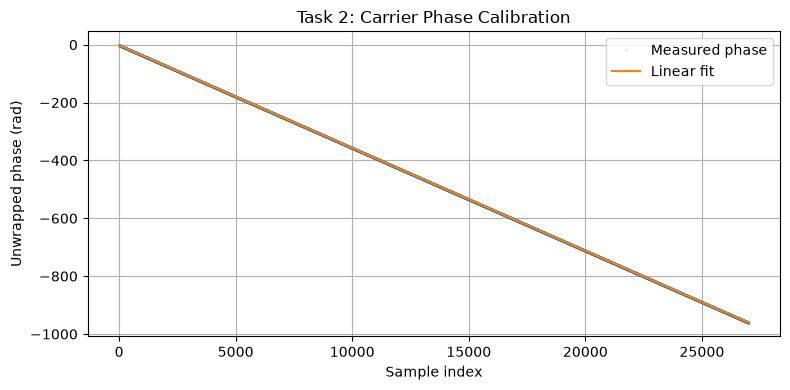

In [75]:
# ============================================================
# Task 2: Carrier Frequency and Phase Offset Calibration
# ============================================================

tx_sdr.tx_destroy_buffer()
time.sleep(0.2)

# Constant complex calibration tone
tx_cal_tone = np.full(
    30000,
    0.25 * tx_scale + 0j,
    dtype=np.complex64
)

tx_sdr.tx_cyclic_buffer = True
rx_sdr.rx_destroy_buffer()

try:
    tx_sdr.tx(tx_cal_tone)
    time.sleep(0.5)

    rx_cal_raw = np.asarray(
        rx_sdr.rx(),
        dtype=np.complex128
    )

finally:
    tx_sdr.tx_destroy_buffer()
    rx_sdr.rx_destroy_buffer()

# Remove settling samples and DC offset
rx_cal = (
    rx_cal_raw[discard_samples:]
    - dc_offset
)

# Sample index
cal_n = np.arange(
    rx_cal.size,
    dtype=np.float64
)

# Unwrapped phase
cal_phase = np.unwrap(
    np.angle(rx_cal)
)

# Linear fit:
# phase[n] = slope*n + intercept
cal_slope, cal_intercept = np.polyfit(
    cal_n,
    cal_phase,
    1
)

# Convert radians/sample to Hz
cfo_hat = (
    cal_slope * fs / (2 * np.pi)
)

# Phase offset wrapped to [-pi, pi]
phase_hat = np.angle(
    np.exp(1j * cal_intercept)
)

print("\n========== TASK 2: CFO/PHASE CALIBRATION ==========")
print(f"Calibration samples    : {rx_cal.size:,}")
print(f"Phase slope            : {cal_slope:.8e} rad/sample")
print(f"CFO estimate           : {cfo_hat:.2f} Hz")
print(f"Phase offset estimate  : {phase_hat:.6f} rad")
print(f"Phase offset           : {np.rad2deg(phase_hat):.3f} degrees")

# Optional visualization of calibration phase
plt.figure(figsize=(8, 4))
plt.plot(
    cal_n,
    cal_phase,
    ".",
    markersize=1,
    alpha=0.3,
    label="Measured phase"
)
plt.plot(
    cal_n,
    cal_slope * cal_n + cal_intercept,
    label="Linear fit"
)
plt.xlabel("Sample index")
plt.ylabel("Unwrapped phase (rad)")
plt.title("Task 2: Carrier Phase Calibration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Task 3: Design the 4-PSK Constellation

Design a four-point constellation:

- All four points at equal distance from the origin.
- Spaced 90° apart from one another.
- One point placed on the positive real (I) axis.

Assign each of the four points a unique 2-bit label using Gray coding, so that any two points
adjacent in phase differ in exactly one bit. Store the result in a form you can look up both
ways: from a 2-bit value to its transmit point, and later, from a received point's decision
back to the 2 bits it represents.

In [3]:
PSK4_A_POINTS = np.array(
    [1 + 0j, 0 + 1j, -1 + 0j, 0 - 1j],
    dtype=np.complex128
)

# Each row contains the two bits assigned to the corresponding point.
PSK4_A_GRAY = np.array(
    [
        [0, 0],  # +1:   0°
        [0, 1],  # +j:  90°
        [1, 1],  # -1: 180°
        [1, 0],  # -j: 270°
    ],
    dtype=np.uint8
)
print('4-PSK A: ')
for z,g in zip(PSK4_A_POINTS, PSK4_A_GRAY) :
    print(f'{g} -> {z.real: .2f} + {z.imag: .2f}j')

4-PSK A: 
[0 0] ->  1.00 +  0.00j
[0 1] ->  0.00 +  1.00j
[1 1] -> -1.00 +  0.00j
[1 0] ->  0.00 + -1.00j


## Task 4: Build the Transmit Frame

Choose a frame length: enough information bits that, even at a fairly low error rate, you can
expect to see enough errors later to estimate the bit error rate reliably. On the order of a
hundred thousand bits is a reasonable target.

Generate that many random bits, group them into 2-bit symbols, and look up each symbol's
transmit point from the mapping you built in Task 3. Turn each complex symbol value into a
rectangular pulse by holding it constant for a fixed number of samples per symbol, and scale
the whole waveform so it uses a modest fraction of the transmitter's full output range rather
than driving the hardware at its limit. Hold on to the original bit sequence — you will need it
later to score errors.

Write this as a function of the symbol mapping rather than hardcoding Task 3's constellation
directly. You will reuse it, unchanged, for the other two constellations later in this lab.

In [77]:
sps = 32

# Fixed, known preamble shared by all three constellations.
# A separate generator keeps preamble creation independent of payload randomness.
preamble_rng = np.random.default_rng(2026)
preamble_n_symbols = 256

preamble_points = np.array(
    [1 + 0j, 0 + 1j, -1 + 0j, 0 - 1j],
    dtype=np.complex128
)

preamble_symbols = preamble_rng.integers(
    0, 4, size=preamble_n_symbols
)
preamble = preamble_points[preamble_symbols]

# Common scaling preserves equal symbol energy across the lab.
frame_amplitude = 0.25 * tx_scale

# Known sample-level reference for synchronization in Task 5.
preamble_waveform = (
    frame_amplitude * np.repeat(preamble, sps)
).astype(np.complex64)

preamble_n_samples = preamble_waveform.size


def build_tx_frame(points, gray_labels, n_bits):
    """
    Frame layout:
        [known preamble | random payload]

    Return:
        tx_bits:     payload bits only, shape (n_bits,)
        tx_symbols:  payload constellation indices, shape (n_bits // 2,)
        tx_waveform: preamble + payload samples, dtype complex64
    """
    points = np.asarray(points, dtype=np.complex128)
    gray_labels = np.asarray(gray_labels)

    if not isinstance(n_bits, (int, np.integer)) or n_bits <= 0 or n_bits % 2:
        raise ValueError("n_bits must be a positive, even integer.")

    if points.shape != (4,) or not np.all(np.isfinite(points)):
        raise ValueError("points must contain four finite complex values.")

    if np.unique(points).size != 4:
        raise ValueError("The four constellation points must be distinct.")

    if gray_labels.shape != (4, 2):
        raise ValueError("gray_labels must have shape (4, 2).")

    if not np.all((gray_labels == 0) | (gray_labels == 1)):
        raise ValueError("gray_labels must contain only 0 and 1.")

    # Convert each two-bit label to an integer: 00=0, 01=1, 10=2, 11=3.
    label_values = (
        2 * gray_labels[:, 0].astype(np.int64)
        + gray_labels[:, 1].astype(np.int64)
    )

    if np.unique(label_values).size != 4:
        raise ValueError("Each two-bit label must appear exactly once.")

    # Inverse lookup: bit-pair value -> constellation index.
    label_to_index = np.empty(4, dtype=np.int64)
    label_to_index[label_values] = np.arange(4)

    # Generate the payload.
    tx_bits = np.random.randint(0, 2, size=n_bits).astype(np.uint8)
    bit_pairs = tx_bits.reshape(-1, 2)
    bit_values = 2 * bit_pairs[:, 0] + bit_pairs[:, 1]

    tx_symbols = label_to_index[bit_values]
    payload_symbols = points[tx_symbols]

    # Rectangular pulse shaping: hold each symbol for sps samples.
    payload_waveform = (
        frame_amplitude * np.repeat(payload_symbols, sps)
    ).astype(np.complex64)

    # Place the known preamble immediately before the payload.
    tx_waveform = np.concatenate(
        (preamble_waveform, payload_waveform)
    )

    return tx_bits, tx_symbols, tx_waveform


n_bits = 1000

tx_bits_a, tx_symbols_a, tx_waveform_a = build_tx_frame(
    PSK4_A_POINTS, PSK4_A_GRAY, n_bits
)

print(f"Preamble: {preamble_n_symbols:,} symbols")
print(f"Preamble samples: {preamble_n_samples:,}")
print(f"Payload bits: {tx_bits_a.size:,}")
print(f"Total frame samples: {tx_waveform_a.size:,}")
print(f"Frame duration: {tx_waveform_a.size / fs:.6f} s")

Preamble: 256 symbols
Preamble samples: 8,192
Payload bits: 1,000
Total frame samples: 24,192
Frame duration: 0.024192 s


## Task 5: Transmit and Capture

Size the receive buffer to comfortably hold at least one full frame with room to spare. Send
the waveform using a cyclic transmit buffer, so the frame repeats continuously while you
capture, then grab a burst of receive samples. As in Tasks 1 and 2, the very start of a capture
is still settling, so discard an initial stretch of it.

Before doing anything else with the captured samples, subtract the DC offset from Task 1, then
undo the frequency and phase rotation estimated in Task 2 by multiplying against the matching
complex exponential. Every later step in this lab assumes both corrections have already been
applied.

Write this, too, as a function of the waveform being sent, so the same procedure can be reused
for the other two constellations without being retyped.

In [78]:

def transmit_and_capture(tx_waveform, tx_gain_db=-10):
    """
    Transmit one frame cyclically and return one synchronized payload.

    Applies:
        1. Idle DC-offset subtraction.
        2. Task 2 CFO and phase correction.
        3. Preamble detection.
        4. Preamble-based residual CFO, phase, and amplitude correction.

    Returned samples exclude the preamble and retain sps samples/symbol.
    """
    tx_waveform = np.asarray(tx_waveform, dtype=np.complex64)

    if tx_waveform.ndim != 1 or not np.all(np.isfinite(tx_waveform)):
        raise ValueError("tx_waveform must be a finite, 1-D complex array.")

    frame_samples = tx_waveform.size
    payload_samples = frame_samples - preamble_n_samples

    if payload_samples <= 0 or payload_samples % sps:
        raise ValueError("Expected a preamble followed by whole payload symbols.")

    if not np.array_equal(
        tx_waveform[:preamble_n_samples], preamble_waveform
    ):
        raise ValueError("The waveform does not start with the Task 4 preamble.")

    previous_buffer_size = int(rx_sdr.rx_buffer_size)

    tx_sdr.tx_destroy_buffer()
    rx_sdr.rx_destroy_buffer()
    time.sleep(0.2)

    try:
        tx_sdr.tx_hardwaregain_chan0 = float(tx_gain_db)

        # After discarding startup samples, retain two frame lengths.
        # This accommodates an arbitrary starting point in the cyclic stream.
        rx_sdr.rx_buffer_size = (
            2 * frame_samples + discard_samples
        )

        tx_sdr.tx_cyclic_buffer = True
        tx_sdr.tx(tx_waveform)
        time.sleep(0.5)

        rx_raw = np.asarray(rx_sdr.rx(), dtype=np.complex128)

    finally:
        tx_sdr.tx_destroy_buffer()
        rx_sdr.rx_destroy_buffer()
        rx_sdr.rx_buffer_size = previous_buffer_size

    if rx_raw.ndim != 1 or not np.all(np.isfinite(rx_raw)):
        raise RuntimeError("Invalid RX capture.")

    rx = rx_raw[discard_samples:] - dc_offset

    if rx.size < 2 * frame_samples:
        raise RuntimeError("RX capture is shorter than the requested two frames.")

    # Task 2 correction, using a local time origin.
    # Preamble processing below resolves this capture's remaining phase.
    sample_n = np.arange(rx.size, dtype=np.float64)
    rx *= np.exp(
        -1j * (
            2 * np.pi * cfo_hat * sample_n / fs
            + phase_hat
        )
    )

    def locate_preamble(samples):
        """Normalized complex correlation, evaluated using NumPy FFTs."""
        reference = preamble_waveform.astype(np.complex128)
        reference_energy = np.vdot(reference, reference).real
        m = reference.size

        # Linear convolution with the conjugate-reversed reference.
        convolution_length = samples.size + m - 1
        fft_size = 1 << (convolution_length - 1).bit_length()

        correlation = np.fft.ifft(
            np.fft.fft(samples, fft_size)
            * np.fft.fft(np.conj(reference[::-1]), fft_size)
        )

        # Consider only starts with a complete following payload.
        candidate_count = samples.size - frame_samples + 1
        correlation = correlation[
            m - 1 : m - 1 + candidate_count
        ]

        cumulative_energy = np.concatenate((
            [0.0],
            np.cumsum(np.abs(samples) ** 2, dtype=np.float64)
        ))
        window_energy = (
            cumulative_energy[m : m + candidate_count]
            - cumulative_energy[:candidate_count]
        )

        denominator = np.sqrt(
            reference_energy * np.maximum(window_energy, 0.0)
        )

        scores = np.zeros(candidate_count, dtype=np.float64)
        np.divide(
            np.abs(correlation),
            denominator,
            out=scores,
            where=denominator > 0
        )

        start = int(np.argmax(scores))
        return start, float(scores[start])

    preamble_start, sync_score = locate_preamble(rx)

    # Practical acquisition threshold, not a universal hardware constant.
    if sync_score < 0.35:
        raise RuntimeError(
            f"Preamble detection unreliable (score={sync_score:.3f}). "
            "Check signal strength and repeat Task 2 if CFO has drifted."
        )

    # Read the middle of each known preamble symbol.
    pilot_positions = (
        preamble_start
        + sps // 2
        + sps * np.arange(preamble_n_symbols)
    )

    # Remove known pilot modulation; the remainder is the channel phasor.
    pilot_channel = rx[pilot_positions] / (
        frame_amplitude * preamble
    )

    pilot_time = (
        pilot_positions - pilot_positions[0]
    ).astype(np.float64) / fs

    pilot_phase = np.unwrap(np.angle(pilot_channel))
    residual_slope, _ = np.polyfit(pilot_time, pilot_phase, 1)
    residual_cfo = residual_slope / (2 * np.pi)

    # Remove residual frequency rotation across the entire capture.
    rx *= np.exp(
        -1j * residual_slope
        * (sample_n - pilot_positions[0]) / fs
    )

    # Refine frame timing after the residual CFO correction.
    preamble_start, sync_score = locate_preamble(rx)

    if sync_score < 0.35:
        raise RuntimeError(
            f"Synchronization failed after refinement "
            f"(score={sync_score:.3f})."
        )

    pilot_positions = (
        preamble_start
        + sps // 2
        + sps * np.arange(preamble_n_symbols)
    )

    # Estimate one complex channel gain from the known preamble.
    # This includes received amplitude and capture-specific phase.
    channel_hat = np.mean(
        rx[pilot_positions] / preamble
    )

    if not np.isfinite(channel_hat) or abs(channel_hat) == 0:
        raise RuntimeError("Invalid preamble channel estimate.")

    payload_start = preamble_start + preamble_n_samples
    payload_end = payload_start + payload_samples

    # Normalize into the same units as the ideal constellation points.
    rx_payload = rx[payload_start:payload_end] / channel_hat

    print(f"TX gain: {tx_gain_db:.1f} dB")
    print(f"Preamble start after discard: {preamble_start:,}")
    print(f"Normalized preamble correlation: {sync_score:.3f}")
    print(f"Residual CFO estimate: {residual_cfo:+.3f} Hz")
    print(f"Payload samples returned: {rx_payload.size:,}")

    return rx_payload


rx_a = transmit_and_capture(tx_waveform_a)

TX gain: -10.0 dB
Preamble start after discard: 21,793
Normalized preamble correlation: 0.997
Residual CFO estimate: +19.112 Hz
Payload samples returned: 16,000


## Task 6: Visualize the Receiver Chain

From `rx_a`, pick one representative sample from the middle of each symbol's pulse, spaced by
your samples-per-symbol value, the same way a rectangular pulse's near-constant middle made
single-sample readings reasonable for amplitude. Keep both the full sample sequence and this
once-per-symbol sequence.

Produce a single figure with three panels, side by side.

1. A scatter plot of the once-per-symbol samples in the I/Q plane, with the four ideal
   constellation points from Task 3 marked on top, so you can see how tightly the received
   points cluster around where they should be.
2. A histogram of the once-per-symbol samples' phase angles, so you can see whether four
   distinct clusters are visible above the noise floor.
3. A plot of phase angle against sample index across the entire capture, so you can confirm
   the correction from Task 2 has left the phase flat over time rather than drifting.

Label every axis and give each panel a title.

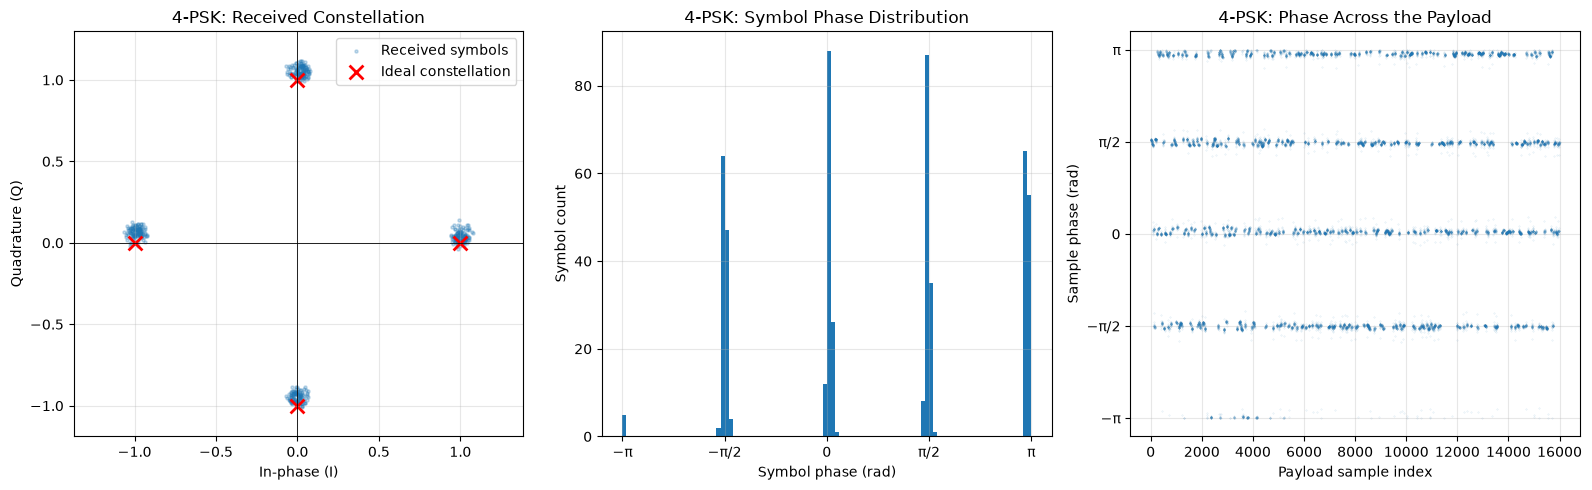

In [79]:
# One sample from the middle of each aligned symbol.
rx_center_a = rx_a[sps // 2::sps]
rx_phase_a = np.angle(rx_center_a)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.scatter(
    rx_center_a.real,
    rx_center_a.imag,
    s=5,
    alpha=0.25,
    label="Received symbols"
)
plt.scatter(
    PSK4_A_POINTS.real,
    PSK4_A_POINTS.imag,
    color="red",
    marker="x",
    s=100,
    linewidths=2,
    label="Ideal constellation"
)
plt.axhline(0, color="black", linewidth=0.6)
plt.axvline(0, color="black", linewidth=0.6)
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title("4-PSK: Received Constellation")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(
    rx_phase_a,
    bins=100,
    range=(-np.pi, np.pi),
    edgecolor="none"
)
plt.xticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    ["−π", "−π/2", "0", "π/2", "π"]
)
plt.xlabel("Symbol phase (rad)")
plt.ylabel("Symbol count")
plt.title("4-PSK: Symbol Phase Distribution")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(
    np.arange(rx_a.size),
    np.angle(rx_a),
    linestyle="none",
    marker=".",
    markersize=0.5,
    alpha=0.2,
    rasterized=True
)
plt.yticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    ["−π", "−π/2", "0", "π/2", "π"]
)
plt.xlabel("Payload sample index")
plt.ylabel("Sample phase (rad)")
plt.title("4-PSK: Phase Across the Payload")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Task 7: Symbol Decision and Bit Recovery

Using the four ideal constellation points from Task 3 as reference, decide which point each
value in your once-per-symbol sequence is closest to. Record that decision as a 2-bit symbol,
using the same Gray-coded mapping you built earlier, then concatenate the recovered symbols'
bits into one long sequence, in the same order the original bits were transmitted, so it can be
compared directly against your transmitted bit sequence.

Write this as a function of the constellation and once-per-symbol samples, rather than
hardcoding Task 3's points directly — you will reuse it for the other two constellations later
in this lab.

In [80]:
def decide_symbols(rx_center, points, gray_labels):
    """
    Decide the nearest constellation point for each received symbol
    and return its Gray-coded bits in transmission order.
    """
    rx_center = np.asarray(rx_center, dtype=np.complex128)
    points = np.asarray(points, dtype=np.complex128)
    gray_labels = np.asarray(gray_labels)

    if rx_center.ndim != 1:
        raise ValueError("rx_center must be a 1-D array.")

    if points.shape != (4,) or gray_labels.shape != (4, 2):
        raise ValueError("Expected four points and four two-bit labels.")

    if not np.all(np.isfinite(rx_center)):
        raise ValueError("Received samples contain NaN or infinite values.")

    # Each row holds one sample's squared distance to all four points.
    distances_squared = np.abs(
        rx_center[:, None] - points[None, :]
    ) ** 2

    # Index of the closest constellation point for each received sample.
    detected_indices = np.argmin(distances_squared, axis=1)

    # Map point indices to bit pairs, then concatenate in symbol order.
    return gray_labels[detected_indices].reshape(-1).astype(np.uint8)


rx_bits_a = decide_symbols(
    rx_center_a, PSK4_A_POINTS, PSK4_A_GRAY
)

## Task 8: Measure the Bit Error Rate

Compare your recovered bits against the transmitted bits, position by position, for the single
frame you just captured. Don't capture additional frames and pool them together — a single
frame's error count already tells you what you need, and averaging across frames would hide
the burst-to-burst variability you're trying to observe.

Count how many bit positions disagree, and report that count as a fraction of the total number
of bits in the frame. Write this as a function of the two bit sequences being compared, so you
can reuse it for the other two constellations later in this lab.

In [81]:
def measure_ber(tx_bits, rx_bits):
    """
    Return the fraction of differing bits in one complete payload frame.
    """
    tx_bits = np.asarray(tx_bits)
    rx_bits = np.asarray(rx_bits)

    if tx_bits.ndim != 1 or rx_bits.ndim != 1:
        raise ValueError("Both bit sequences must be 1-D arrays.")

    if tx_bits.size == 0:
        raise ValueError("The transmitted bit sequence must not be empty.")

    if tx_bits.size != rx_bits.size:
        raise ValueError(
            f"Bit counts differ: TX={tx_bits.size}, RX={rx_bits.size}. "
            "Check frame extraction and symbol sampling."
        )

    if not (
        np.all((tx_bits == 0) | (tx_bits == 1))
        and np.all((rx_bits == 0) | (rx_bits == 1))
    ):
        raise ValueError("Both sequences must contain only 0 and 1.")

    return np.count_nonzero(tx_bits != rx_bits) / tx_bits.size


ber_a = measure_ber(tx_bits_a, rx_bits_a)

print(f"Bit errors: {np.count_nonzero(tx_bits_a != rx_bits_a):,}")
print(f"Bits compared: {tx_bits_a.size:,}")
print(f"4-PSK (0 deg) BER: {ber_a:.2e}")

Bit errors: 0
Bits compared: 1,000
4-PSK (0 deg) BER: 0.00e+00


## Task 9: Bit Error Rate versus Transmit Gain — 4-PSK (0°)

Repeat the transmit-capture-decide-score procedure from Tasks 4 through 8 at several different
transmit hardware gain settings, holding the receive gain fixed throughout, to see how the bit
error rate responds as the received signal strength changes relative to a fixed noise floor.

Wrap the full procedure in a function, so you can call it once per gain setting without
retyping it. Give that function a parameter for which decision function to use rather than
calling `decide_symbols` by name internally — later in this lab you will sweep a constellation
that uses a different one. Sweep a handful of gain values spanning from clearly error-free down
to clearly unusable. Plot the resulting bit error rate on a logarithmic vertical axis against
the gain values on a linear horizontal axis.



TX Gain = -70.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.098).
BER = unavailable

TX Gain = -68.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.118).
BER = unavailable

TX Gain = -66.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.134).
BER = unavailable

TX gain: -64.0 dB
Preamble start after discard: 11,936
Normalized preamble correlation: 0.782
Residual CFO estimate: -6.836 Hz
Payload samples returned: 16,000
TX Gain = -64.0 dB
Complete payload frames scored: 1
Recovered data bits: 1000
Bits compared: 1000
Bit errors: 138
BER = 1.3800e-01

TX gain: -62.0 dB
Preamble start after discard: 12,131
Normalized preamble correlation: 0.836
Residual CFO estimate: -11.032 Hz
Payload samples returned: 16,000
TX Gain = -62.0 dB
Complete payload frames scored: 1
Recovered data bits: 1000
Bits compared: 1000
Bit errors: 57
BER = 5.7000e-02

TX gain: -60.0 dB
Preamble start after discard: 6,048
No

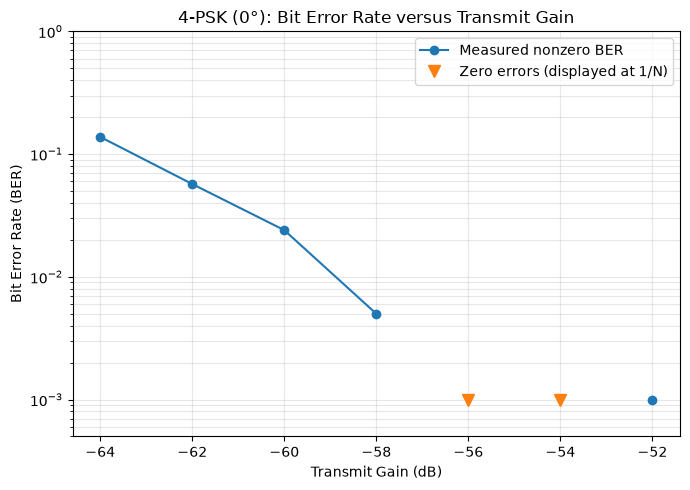

In [185]:
# ============================================================
# Task 9: Bit Error Rate versus Transmit Gain — 4-PSK (0°)
# ============================================================

def measure_ber_at_gain(
    tx_gain_db,
    points=PSK4_A_POINTS,
    gray_labels=PSK4_A_GRAY,
    n_bits=n_bits,
    decide_fn=decide_symbols
):

    # ========================================================
    # Task 4: Build a fresh frame with the known preamble
    # ========================================================

    tx_bits, tx_symbols, tx_waveform = build_tx_frame(
        points,
        gray_labels,
        n_bits
    )

    # ========================================================
    # Task 5: Transmit, calibrate, and detect the preamble
    # ========================================================

    # Returns exactly one aligned payload, excluding the preamble.
    # Includes DC, frequency, phase, and amplitude corrections.
    try:
        rx = transmit_and_capture(
            tx_waveform,
            tx_gain_db=float(tx_gain_db)
        )

    except RuntimeError as error:
        print(f"TX Gain = {tx_gain_db:.1f} dB")
        print(f"Frame acquisition failed: {error}")
        print("BER = unavailable")

        # Failed acquisition is not a measured bit error rate.
        return np.nan

    # ========================================================
    # Task 6: Symbol-center sampling
    # ========================================================

    rx_center = rx[sps // 2::sps]

    # ========================================================
    # Task 7: Symbol decision and bit recovery
    # ========================================================

    rx_bits = decide_fn(
        rx_center,
        points,
        gray_labels
    )

    # ========================================================
    # Task 8: BER calculation for one complete payload
    # ========================================================

    # measure_ber checks that TX and RX lengths match exactly.
    ber = measure_ber(tx_bits, rx_bits)

    n_bit_errors = np.count_nonzero(tx_bits != rx_bits)
    n_compare = tx_bits.size

    # ========================================================
    # Display result
    # ========================================================

    print(f"TX Gain = {tx_gain_db:.1f} dB")
    print("Complete payload frames scored: 1")
    print("Recovered data bits:", rx_bits.size)
    print("Bits compared:", n_compare)
    print("Bit errors:", n_bit_errors)
    print(f"BER = {ber:.4e}")

    return ber


# ============================================================
# Reusable sweep function for Tasks 9, 12, and 16
# ============================================================

def ber_vs_gain(
    points,
    gray_labels,
    n_bits,
    tx_gain_sweep_db,
    decide_fn=decide_symbols
):
    ber_results = []
    previous_tx_gain = float(tx_sdr.tx_hardwaregain_chan0)

    try:
        for gain_db in tx_gain_sweep_db:
            print("\n" + "=" * 45)

            ber = measure_ber_at_gain(
                tx_gain_db=gain_db,
                points=points,
                gray_labels=gray_labels,
                n_bits=n_bits,
                decide_fn=decide_fn
            )

            ber_results.append(ber)

    finally:
        tx_sdr.tx_hardwaregain_chan0 = previous_tx_gain

    return ber_results


# ============================================================
# Sweep different TX gain values
# ============================================================

# -60, -58, ..., -12 dB, matching your example.
tx_gain_sweep_db = np.arange(-70, -50, 2)

ber_results_a = ber_vs_gain(
    PSK4_A_POINTS,
    PSK4_A_GRAY,
    n_bits,
    tx_gain_sweep_db
)


# ============================================================
# Plot BER versus TX gain
# ============================================================

ber_values = np.asarray(ber_results_a, dtype=float)

zero_errors = np.isfinite(ber_values) & (ber_values == 0)
nonzero_ber = np.where(ber_values > 0, ber_values, np.nan)

plt.figure(figsize=(7, 5))

plt.semilogy(
    tx_gain_sweep_db,
    nonzero_ber,
    marker="o",
    label="Measured nonzero BER"
)

# Zero cannot be shown on a logarithmic axis.
# Display it with a separate marker without changing stored BER.
if np.any(zero_errors):
    plt.semilogy(
        tx_gain_sweep_db[zero_errors],
        np.full(np.count_nonzero(zero_errors), 1.0 / n_bits),
        marker="v",
        linestyle="none",
        markersize=8,
        label="Zero errors (displayed at 1/N)"
    )

plt.xlabel("Transmit Gain (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("4-PSK (0°): Bit Error Rate versus Transmit Gain")
plt.ylim(0.5 / n_bits, 1)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Task 10: Design a Rotated 4-PSK Constellation

Design a second four-point constellation with the same magnitude and spacing as Task 3 — four
points, equally spaced 90° apart — but rotate the whole arrangement by 30° so that none of its
points fall on either axis. Every point from Task 3 should now sit 30° further along the circle
than it did before.

Assign new 2-bit Gray-coded labels to these rotated points, following the same rule as Task 3:
any two points adjacent in phase should differ in exactly one bit. Store the mapping the same
way you did before, in both directions.

In [83]:
PSK4_B_POINTS = PSK4_A_POINTS * np.exp(1j * np.deg2rad(30))

PSK4_B_GRAY = PSK4_A_GRAY.copy()

print('4-PSK B: ')
for z,g in zip(PSK4_B_POINTS, PSK4_B_GRAY) :
    print(f'{g} -> {z.real: .2f} + {z.imag: .2f}j')

4-PSK B: 
[0 0] ->  0.87 +  0.50j
[0 1] -> -0.50 +  0.87j
[1 1] -> -0.87 + -0.50j
[1 0] ->  0.50 + -0.87j


## Task 11: Repeat for the Rotated Constellation

Run the same transmit, capture, and decision procedure you built in Tasks 4, 5, and 7 on this
new constellation, and measure its bit error rate as in Task 8. If those tasks were written as
functions of the constellation and its Gray coding rather than hardcoded to Task 3's specific
points, this should take no new code beyond calling what you already have with
`PSK4_B_POINTS` and `PSK4_B_GRAY` in place of `PSK4_A_POINTS` and `PSK4_A_GRAY`.

The frame length and buffer sizing from Task 4 and Task 5 carry over unchanged — this
constellation has the same number of points as the last one, so nothing about the frame's
size needs to be recomputed.

In [187]:
tx_bits_b, tx_symbols_b, tx_waveform_b = build_tx_frame(
    PSK4_B_POINTS,
    PSK4_B_GRAY,
    n_bits
)

rx_b = transmit_and_capture(tx_waveform_b)

# Task 5 returns the aligned payload without the preamble.
rx_center_b = rx_b[sps // 2::sps]

rx_bits_b = decide_symbols(
    rx_center_b,
    PSK4_B_POINTS,
    PSK4_B_GRAY
)

ber_b = measure_ber(tx_bits_b, rx_bits_b)

print(f"Bit errors: {np.count_nonzero(tx_bits_b != rx_bits_b):,}")
print(f"Bits compared: {tx_bits_b.size:,}")
print(f"4-PSK (30 deg) BER: {ber_b:.2e}")

TX gain: -10.0 dB
Preamble start after discard: 12,968
Normalized preamble correlation: 0.996
Residual CFO estimate: +6.086 Hz
Payload samples returned: 16,000
Bit errors: 0
Bits compared: 1,000
4-PSK (30 deg) BER: 0.00e+00


## Task 12: Bit Error Rate versus Transmit Gain — 4-PSK (30°)

Repeat the gain sweep from Task 9 for the rotated constellation, using the same gain values so
the two curves can be compared directly later. Reuse the `ber_vs_gain` function from Task 9
unchanged; only the constellation and its Gray coding should differ.


TX Gain = -70.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.103).
BER = unavailable

TX gain: -68.0 dB
Preamble start after discard: 4,581
Normalized preamble correlation: 0.608
Residual CFO estimate: +29.690 Hz
Payload samples returned: 16,000
TX Gain = -68.0 dB
Complete payload frames scored: 1
Recovered data bits: 1000
Bits compared: 1000
Bit errors: 508
BER = 5.0800e-01

TX Gain = -66.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.143).
BER = unavailable

TX Gain = -64.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.141).
BER = unavailable

TX gain: -62.0 dB
Preamble start after discard: 12,047
Normalized preamble correlation: 0.843
Residual CFO estimate: +11.810 Hz
Payload samples returned: 16,000
TX Gain = -62.0 dB
Complete payload frames scored: 1
Recovered data bits: 1000
Bits compared: 1000
Bit errors: 76
BER = 7.6000e-02

TX gain: -60.0 dB
Preamble start after discard: 10,833
N

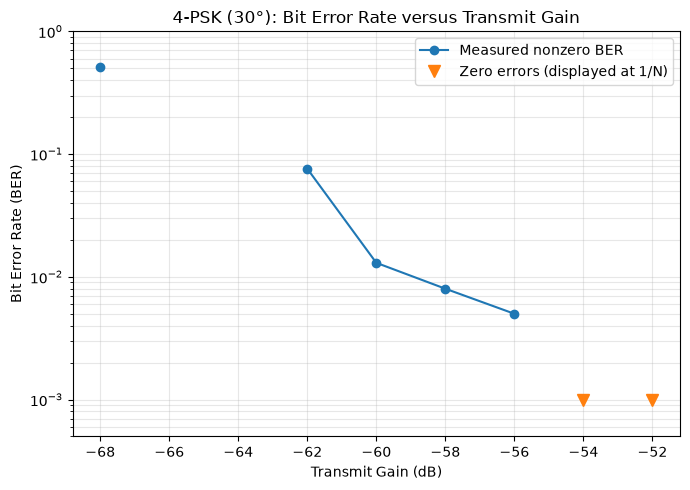

In [188]:
ber_results_b = ber_vs_gain(
    PSK4_B_POINTS,
    PSK4_B_GRAY,
    n_bits,
    tx_gain_sweep_db
)

# Prepare the plot without changing the measured BER values.
ber_values_b = np.asarray(ber_results_b, dtype=float)

zero_errors_b = np.isfinite(ber_values_b) & (ber_values_b == 0)
nonzero_ber_b = np.where(ber_values_b > 0, ber_values_b, np.nan)

plt.figure(figsize=(7, 5))

plt.semilogy(
    tx_gain_sweep_db,
    nonzero_ber_b,
    marker="o",
    label="Measured nonzero BER"
)

if np.any(zero_errors_b):
    plt.semilogy(
        tx_gain_sweep_db[zero_errors_b],
        np.full(np.count_nonzero(zero_errors_b), 1.0 / n_bits),
        marker="v",
        linestyle="none",
        markersize=8,
        label="Zero errors (displayed at 1/N)"
    )

plt.xlabel("Transmit Gain (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("4-PSK (30°): Bit Error Rate versus Transmit Gain")
plt.ylim(0.5 / n_bits, 1)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Task 13: Design the 4-QAM Constellation

Design a third four-point constellation, but this time let each of the two bits act on one
coordinate axis independently: one bit decides the sign of the point's real part, the other
decides the sign of its imaginary part, so the four points land at the four sign combinations
of a fixed real and imaginary magnitude. Match the energy per symbol to the constellations you
designed in Tasks 3 and 10, so the comparison later in this lab isn't confounded by one design
simply transmitting more power than another.

Choose a 2-bit labeling consistent with that independent-bit structure, and store the mapping
in both directions as before.

In [84]:
QAM4_POINTS = np.array(
    [
         1 + 1j,  # 00
         1 - 1j,  # 01
        -1 + 1j,  # 10
        -1 - 1j,  # 11
    ],
    dtype=np.complex128
) / np.sqrt(2)

QAM4_GRAY = np.array(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ],
    dtype=np.uint8
)

for z,g in zip(QAM4_POINTS, QAM4_GRAY):
    print(f'{g} -> {z.real: .2f} + {z.imag: .2f}j ')

[0 0] ->  0.71 +  0.71j 
[0 1] ->  0.71 + -0.71j 
[1 0] -> -0.71 +  0.71j 
[1 1] -> -0.71 + -0.71j 


## Task 14: Decide by Axis, Not by Distance

Task 7's decision rule works by finding whichever of the four constellation points a received
sample sits closest to, and it would still work correctly here. But this constellation was
built with a special structure — each bit controls one coordinate axis, and the two axes act
independently of one another. Before reaching for a full nearest-point search, consider whether
that structure allows a shortcut: a way to decide each of the two bits directly from a single
coordinate of the received sample, without comparing it against every candidate point at all.

Implement that shortcut as a function of the received samples and the constellation's Gray
coding. You will use it, and check it against Task 7's general decision function, once you have
real samples to test it on.

In [85]:
def decide_bits_by_axis(rx_center, points, gray_labels):
    """
    Recover bits from the signs of I and Q for centered square 4-QAM.
    """
    rx_center = np.asarray(rx_center, dtype=np.complex128)
    points = np.asarray(points, dtype=np.complex128)
    gray_labels = np.asarray(gray_labels)

    if rx_center.ndim != 1:
        raise ValueError("rx_center must be a 1-D array.")

    if points.shape != (4,) or gray_labels.shape != (4, 2):
        raise ValueError("Expected four points and four two-bit labels.")

    if not np.all(np.isfinite(rx_center)):
        raise ValueError("Received samples contain NaN or infinite values.")

    # Encode quadrants: ++ = 0, +- = 1, -+ = 2, -- = 3.
    point_quadrants = (
        2 * (points.real < 0).astype(int)
        + (points.imag < 0).astype(int)
    )

    if (
        np.unique(point_quadrants).size != 4
        or np.any(points.real == 0)
        or np.any(points.imag == 0)
        or not np.allclose(np.abs(points.real), np.abs(points.real[0]))
        or not np.allclose(np.abs(points.imag), np.abs(points.real[0]))
    ):
        raise ValueError("points must describe a centered square 4-QAM constellation.")

    quadrant_to_index = np.empty(4, dtype=int)
    quadrant_to_index[point_quadrants] = np.arange(4)

    rx_quadrants = (
        2 * (rx_center.real < 0).astype(int)
        + (rx_center.imag < 0).astype(int)
    )
    detected_indices = quadrant_to_index[rx_quadrants]

    # On a decision boundary, match np.argmin's first-index tie rule.
    on_boundary = (rx_center.real == 0) | (rx_center.imag == 0)

    for k in np.flatnonzero(on_boundary):
        candidates = (
            ((rx_center[k].real == 0)
             | ((points.real < 0) == (rx_center[k].real < 0)))
            &
            ((rx_center[k].imag == 0)
             | ((points.imag < 0) == (rx_center[k].imag < 0)))
        )
        detected_indices[k] = np.flatnonzero(candidates)[0]

    return gray_labels[detected_indices].reshape(-1).astype(np.uint8)

## Task 15: Repeat for 4-QAM

Run the transmit and capture procedure from Tasks 4 and 5 on the 4-QAM constellation from
Task 13. Decide symbols two ways — using Task 7's general nearest-point function, and using
Task 14's axis-based shortcut — and confirm the two agree on every recovered bit before moving
on. Measure the bit error rate, using either one, as in Task 8.

In [191]:
tx_bits_c, tx_symbols_c, tx_waveform_c = build_tx_frame(
    QAM4_POINTS,
    QAM4_GRAY,
    n_bits
)

rx_c = transmit_and_capture(tx_waveform_c)

# Extract symbol-center samples from the aligned payload.
rx_center_c = rx_c[sps // 2::sps]

rx_bits_c_general = decide_symbols(
    rx_center_c,
    QAM4_POINTS,
    QAM4_GRAY
)

rx_bits_c_axis = decide_bits_by_axis(
    rx_center_c,
    QAM4_POINTS,
    QAM4_GRAY
)

decisions_agree = np.array_equal(
    rx_bits_c_general,
    rx_bits_c_axis
)

print("Decision functions agree:", decisions_agree)

if not decisions_agree:
    raise RuntimeError(
        "The general and axis-based decisions differ. "
        "Check the constellation mapping and decision functions."
    )

ber_c = measure_ber(tx_bits_c, rx_bits_c_axis)

print(f"Bit errors: {np.count_nonzero(tx_bits_c != rx_bits_c_axis):,}")
print(f"Bits compared: {tx_bits_c.size:,}")
print(f"4-QAM BER: {ber_c:.2e}")

TX gain: -10.0 dB
Preamble start after discard: 22,272
Normalized preamble correlation: 0.997
Residual CFO estimate: +25.944 Hz
Payload samples returned: 16,000
Decision functions agree: True
Bit errors: 0
Bits compared: 1,000
4-QAM BER: 0.00e+00


## Task 16: Bit Error Rate versus Transmit Gain — 4-QAM

Repeat the gain sweep from Tasks 9 and 12 for the 4-QAM constellation, using the same gain
values, so all three curves can be compared directly in the next task. Pass Task 14's axis-based
function in as `ber_vs_gain`'s decision function this time, rather than the default.


TX Gain = -70.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.094).
BER = unavailable

TX Gain = -68.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.125).
BER = unavailable

TX Gain = -66.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.127).
BER = unavailable

TX Gain = -64.0 dB
Frame acquisition failed: Synchronization failed after refinement (score=0.134).
BER = unavailable

TX gain: -62.0 dB
Preamble start after discard: 9,653
Normalized preamble correlation: 0.845
Residual CFO estimate: +31.528 Hz
Payload samples returned: 16,000
TX Gain = -62.0 dB
Complete payload frames scored: 1
Recovered data bits: 1000
Bits compared: 1000
Bit errors: 68
BER = 6.8000e-02

TX gain: -60.0 dB
Preamble start after discard: 10,885
Normalized preamble correlation: 0.891
Residual CFO estimate: +27.843 Hz
Payload samples returned: 16,000
TX Gain = -60.0 dB
Complete payload frames scored: 1
Recovered data bi

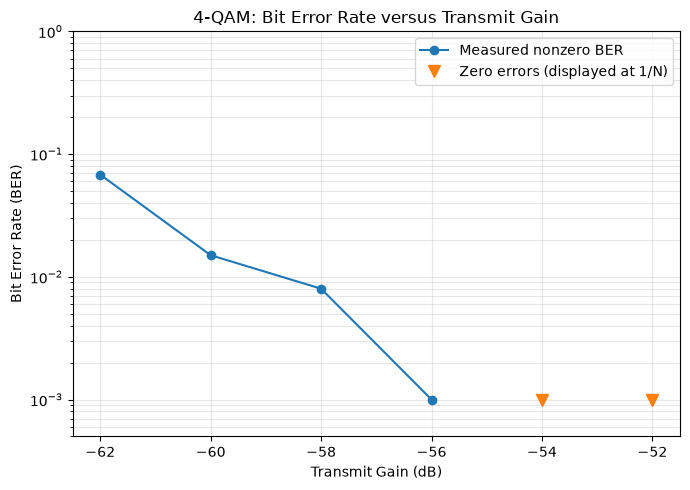

In [192]:
ber_results_c = ber_vs_gain(
    QAM4_POINTS,
    QAM4_GRAY,
    n_bits,
    tx_gain_sweep_db,
    decide_fn=decide_bits_by_axis
)

# Prepare the plot without changing the measured BER values.
ber_values_c = np.asarray(ber_results_c, dtype=float)

zero_errors_c = np.isfinite(ber_values_c) & (ber_values_c == 0)
nonzero_ber_c = np.where(ber_values_c > 0, ber_values_c, np.nan)

plt.figure(figsize=(7, 5))

plt.semilogy(
    tx_gain_sweep_db,
    nonzero_ber_c,
    marker="o",
    label="Measured nonzero BER"
)

if np.any(zero_errors_c):
    plt.semilogy(
        tx_gain_sweep_db[zero_errors_c],
        np.full(np.count_nonzero(zero_errors_c), 1.0 / n_bits),
        marker="v",
        linestyle="none",
        markersize=8,
        label="Zero errors (displayed at 1/N)"
    )

plt.xlabel("Transmit Gain (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("4-QAM: Bit Error Rate versus Transmit Gain")
plt.ylim(0.5 / n_bits, 1)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Task 17: Compare All Three

Plot all three bit error rate curves — from Tasks 9, 12, and 16 — on a single set of axes,
against the same transmit gain values, with a legend identifying each constellation. This is
the comparison the rest of the lab has been building toward.

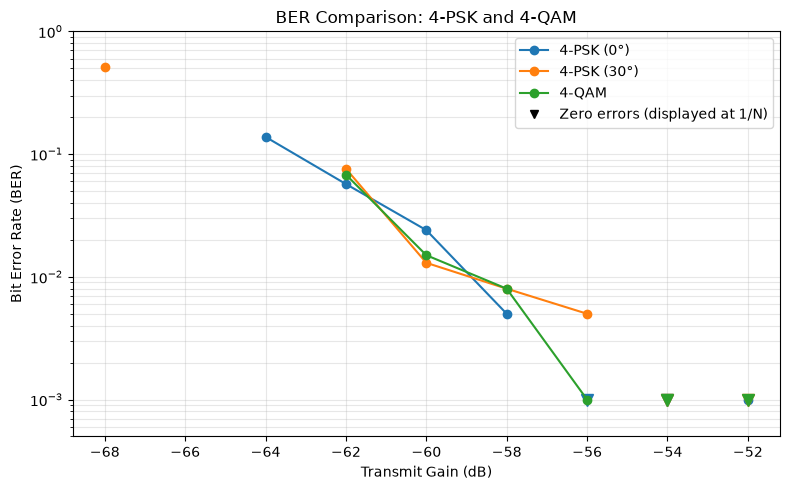

In [193]:
plt.figure(figsize=(8, 5))

for results, label, color in [
    (ber_results_a, "4-PSK (0°)", "C0"),
    (ber_results_b, "4-PSK (30°)", "C1"),
    (ber_results_c, "4-QAM", "C2"),
]:
    ber_values = np.asarray(results, dtype=float)

    if ber_values.shape != np.asarray(tx_gain_sweep_db).shape:
        raise ValueError(f"{label}: BER results and gain settings must match.")

    # Plot measured positive BER; leave gaps for zeros and failed acquisition.
    positive_ber = np.where(ber_values > 0, ber_values, np.nan)

    plt.semilogy(
        tx_gain_sweep_db,
        positive_ber,
        "o-",
        color=color,
        label=label
    )

    # Display zero-error measurements separately without altering results.
    zero_errors = np.isfinite(ber_values) & (ber_values == 0)

    if np.any(zero_errors):
        plt.semilogy(
            np.asarray(tx_gain_sweep_db)[zero_errors],
            np.full(np.count_nonzero(zero_errors), 1.0 / n_bits),
            marker="v",
            linestyle="none",
            color=color,
            markersize=8
        )

# Legend entry explaining the zero-error markers.
plt.plot(
    [], [],
    marker="v",
    linestyle="none",
    color="black",
    label="Zero errors (displayed at 1/N)"
)

plt.xlabel("Transmit Gain (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("BER Comparison: 4-PSK and 4-QAM")
plt.ylim(0.5 / n_bits, 1)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Background

**DC offset and LO leakage.** A small amount of a receiver's own local-oscillator signal
routinely couples into its receive path, and analog mixers and amplifiers carry their own
small imbalances. Together these show up as a constant complex offset added to every sample,
independent of whatever signal is actually arriving over the air. It doesn't average away on
its own, and unless it's measured and removed, it biases the center of every constellation you
capture afterward — a bias that lands most directly on any point whose ideal position happens
to sit close to the origin's neighborhood along the offset's own direction.

**Carrier frequency and phase offset.** Two independently clocked radios never share a
frequency reference exactly. If the transmitter's carrier and the receiver's local oscillator
differ by even a fraction of a hertz, every sample the receiver captures carries an extra phase
term that grows linearly with time — the received phase at sample $n$ is the transmitted phase
plus $2\pi \Delta f\, n / f_s + \phi_0$, where $\Delta f$ is the frequency offset and $\phi_0$ is
whatever phase difference existed the instant the transmitter started. An unmodulated tone makes
both of these directly measurable: its transmitted phase is constant, so any change in the
received phase over the capture is entirely due to $\Delta f$ and $\phi_0$, recoverable from a
linear fit to the unwrapped phase. Every symbol decision made anywhere in this lab implicitly
assumes this rotation has already been undone.

**Constant-modulus constellations and rotation invariance.** In additive Gaussian noise, the
noise added to a transmitted symbol is circularly symmetric — equally likely to point in any
direction in the complex plane. Rotating an entire constellation by a fixed angle rotates its
decision boundaries by exactly the same angle, leaving the geometry between every point and
every boundary completely unchanged. This is why the two constant-modulus designs earlier in
this lab should, in principle, deliver identical bit error rates at a given transmit gain: the
underlying decision problem is the same problem, just described in rotated coordinates. Any
difference you observe between them in practice reflects something the ideal noise model
doesn't capture — most plausibly, how each design's specific point positions interact with a
residual DC offset or some other hardware asymmetry that isn't itself rotationally symmetric.

**Why the square constellation decouples into two independent decisions.** When a constellation
places its four points at every combination of $\pm a$ on the real axis and $\pm a$ on the
imaginary axis, its decision boundaries are exactly the coordinate axes themselves. Deciding
which side of the imaginary axis a received sample falls on determines one bit completely,
regardless of where the sample sits on the real axis, and the same holds in reverse for the
other bit and the real axis. The two decisions never interact. This is the same idea as viewing
this constellation as two independent binary decisions carried on two orthogonal
dimensions — not a coincidence of this particular design, but a direct consequence of building
the constellation as the product of two independent sign choices in the first place. Neither of
the phase-based constellations earlier in the lab has this property: their decision boundaries
are diagonal lines that mix both coordinates together, so no single coordinate can be read off
on its own.

## Questions

1. Write down $E_s$ for each of this lab's three constellations in terms of the design
   parameters you chose, and confirm they are equal by construction. What is $E_b$ for each,
   given 2 bits per symbol?

2. Derive the maximum-likelihood decision rule for an $M$-ary constellation in AWGN, and show
   that for equally likely, equal-energy symbols it reduces to "decide the point closest in
   Euclidean distance." Then explain why, for the two constellations built in Tasks 3 and 10,
   this reduces further to "decide the point closest in phase," while for the constellation in
   Task 13, it reduces further still to two independent sign decisions.

3. Under ideal AWGN, use a union bound argument to show that the constellations from Tasks 3,
   10, and 13 should all have the same symbol error probability at a given $E_s/N_0$. If your
   Task 17 comparison shows a visible difference between them, what non-ideal effect in the
   hardware would you look at first, and why?

4. If your Task 2 frequency offset estimate were off by even a small amount, every symbol later
   in the frame would arrive rotated by an angle that grows with its position in the capture.
   Which of your Task 6 panels would reveal this first, and what would it look like there?

5. The DC offset measured in Task 1 is a fixed point in the I/Q plane, independent of the
   transmitted signal. For which of this lab's three constellations would a small residual DC
   offset be most damaging to symbol decisions, and why?

### Plan

1. tx should should cyclic and it should have start bit and stop bit.
2. rx buffer find 1st start bit and stop bit consider it for demodulation and decoding (plot rx wrt to time with satrt and stop region)
3. use start bit and find cfo and initial phase
4. correct cfo and initial phase
5. use sps 32 find max no of symbols point to which and make a decision of symbol and map and decode two bits

## Answer

1. For all three constellations, we designed the points with the same energy, \(E_s=1\). Since each symbol carries 2 bits, \(E_b=E_s/2=1/2\).
Therefore, all three have equal \(E_s\) and \(E_b\) by construction.

2. In AWGN, choose the constellation point with the smallest Euclidean distance from the received point. For 4-PSK, all points have the same amplitude, so this is the point with the closest phase. For 4-QAM, the decision can be made independently using the sign of I and Q.

3. All three constellations have the same \(E_s\) and the same minimum distance, so ideally they should have the same symbol error probability.
If Task 17 shows a difference, first check DC offset or IQ imbalance in the hardware. These imperfections can move or distort the received constellation.

4. The third panel of Task 6 (phase vs sample index) will show this first.
Instead of a stable/flat phase, the phase will show a gradually increasing or decreasing slope. This means the constellation is continuously rotating with time.

5. A residual DC offset would be most damaging to 4-QAM, because its decision boundaries are directly on the I and Q axes. Even a small shift can move points across these boundaries. Thus, DC offset can cause more symbol errors in 4-QAM.
